### Water Classification: VGG16 vs. EfficientNetB0 vs. Custom CNN

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from pathlib import Path
import tensorflow as tf
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.layers import Input, Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

In [ ]:
DATASET_PATH = Path("./prepared_dataset")
SAVED_MODELS_PATH = Path("./models")
SAVED_MODELS_PATH.mkdir(exist_ok=True)

# Model & Training Parameters
IMG_SIZE_VGG = (224, 224)   
IMG_SIZE_CNN = (128, 128)   
BATCH_SIZE = 32
EPOCHS = 50           
PATIENCE = 10         
LEARNING_RATE = 0.0001 

In [ ]:
water_paths = list(DATASET_PATH.glob('Water/*.jpg'))
not_water_paths = list(DATASET_PATH.glob('Not_Water/*.jpg'))

water_labels = ['Water'] * len(water_paths)
not_water_labels = ['Not_Water'] * len(not_water_paths)

all_paths = water_paths + not_water_paths
all_labels = water_labels + not_water_labels

data_df = pd.DataFrame({
    'filepath': all_paths,
    'label': all_labels
})

data_df = data_df.sample(frac=1, random_state=42).reset_index(drop=True)

data_df['filepath'] = data_df['filepath'].astype(str)

train_df, temp_df = train_test_split(
    data_df,
    test_size=0.3,
    random_state=42,
    stratify=data_df['label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=(10/30), 
    random_state=42,
    stratify=temp_df['label']
)

print(f"Total images:     {len(data_df)}")
print(f"Training images:  {len(train_df)} (70.0%)")
print(f"Validation images: {len(val_df)} (20.0%)")
print(f"Test images:      {len(test_df)} (10.0%)")

print("\nTraining distribution:\n", train_df['label'].value_counts())
print("\nValidation distribution:\n", val_df['label'].value_counts())
print("\nTest distribution:\n", test_df['label'].value_counts())

Total images:     6400
Training images:  4480 (70.0%)
Validation images: 1280 (20.0%)
Test images:      640 (10.0%)

Training distribution:
 label
Not_Water    2240
Water        2240
Name: count, dtype: int64

Validation distribution:
 label
Not_Water    640
Water        640
Name: count, dtype: int64

Test distribution:
 label
Not_Water    320
Water        320
Name: count, dtype: int64


In [ ]:
# Data Generator for VGG16 
train_datagen_vgg = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2
)

# Test/Validation Generator for VGG16 
test_datagen_vgg = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Data Generator for Custom CNN 
train_datagen_cnn = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,   # Good to have
    rotation_range=20,      # NEW: Randomly rotate images
    width_shift_range=0.2,  # NEW: Shift image horizontally
    height_shift_range=0.2, # NEW: Shift image vertically
    zoom_range=0.2,         # You had this, keep it
    shear_range=0.2,        # You had this, keep it
    fill_mode='nearest'     # Fills in pixels after a shift/zoom
)

# Test/Validation Generator for Custom CNN 
test_datagen_cnn = ImageDataGenerator(
    rescale=1./255
)

# VGG16 Generators
train_gen_vgg = train_datagen_vgg.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE_VGG,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen_vgg = test_datagen_vgg.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE_VGG,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen_vgg = test_datagen_vgg.flow_from_dataframe(
    test_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE_VGG,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Custom CNN Generators
train_gen_cnn = train_datagen_cnn.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE_CNN,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen_cnn = test_datagen_cnn.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE_CNN,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen_cnn = test_datagen_cnn.flow_from_dataframe(
    test_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE_CNN,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


# Data Generator for EfficientNet 
train_datagen_eff = ImageDataGenerator(
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
)

# Test/Validation Generator for EfficientNet 
test_datagen_eff = ImageDataGenerator() 

# EfficientNet Generators 
train_gen_eff = train_datagen_eff.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE_VGG, # Reuse 224x224
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen_eff = test_datagen_eff.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE_VGG,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen_eff = test_datagen_eff.flow_from_dataframe(
    test_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE_VGG,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

In [ ]:
def plot_history(history, model_name):
    try:
        acc = history.history['accuracy']
        val_acc = history.history['val_accuracy']
        loss = history.history['loss']
        val_loss = history.history['val_loss']
        epochs_range = range(len(acc))

        plt.figure(figsize=(14, 6))
        
        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, acc, label='Training Accuracy')
        plt.plot(epochs_range, val_acc, label='Validation Accuracy')
        plt.legend(loc='lower right')
        plt.title(f'{model_name} - Training and Validation Accuracy')

        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, loss, label='Training Loss')
        plt.plot(epochs_range, val_loss, label='Validation Loss')
        plt.legend(loc='upper right')
        plt.title(f'{model_name} - Training and Validation Loss')
        
        plt.savefig(f"{model_name}_training_history.png")
        print(f"Saved plot to {model_name}_training_history.png")
        plt.show()
    except Exception as e:
        print(f"Error plotting history: {e}")

In [ ]:
def create_vgg16_model(input_shape):
    base_model = VGG16(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
        pooling='avg'
    )
    
    base_model.trainable = False
    
    inputs = base_model.input
    x = base_model.output
    outputs = Dense(2, activation='softmax', name='output_layer')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print("VGG16 model built successfully.")
    model.summary()
    return model

vgg_model = create_vgg16_model(input_shape=(*IMG_SIZE_VGG, 3))

I0000 00:00:1762862396.057323   10186 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4309 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


VGG16 model built successfully.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,715,714 (56.14 MB)

 Trainable params: 1,026 (4.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [9]:
vgg_callbacks = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
    ModelCheckpoint(
        filepath=str(SAVED_MODELS_PATH / 'vgg16_best.keras'),
        monitor='val_loss',
        save_best_only=True
    )
]

print("\n--- Training VGG16 Model ---")
vgg_history = vgg_model.fit(
    train_gen_vgg,
    epochs=EPOCHS,
    validation_data=val_gen_vgg,
    callbacks=vgg_callbacks
)


--- Training VGG16 Model ---
Epoch 1/50


2025-11-11 09:00:47.638619: I external/local_xla/xla/service/service.cc:163] XLA service 0x74a04c00b180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-11 09:00:47.638648: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6
2025-11-11 09:00:47.669034: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-11 09:00:47.847095: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300
2025-11-11 09:00:57.879329: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng13{} for conv (f32[32,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,224,224]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBia

140/140 ━━━━━━━━━━━━━━━━━━━━ 128s 558ms/step - accuracy: 0.6116 - loss: 1.2038 - val_accuracy: 0.6500 - val_loss: 1.0462
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 43s 309ms/step - accuracy: 0.7085 - loss: 0.7721 - val_accuracy: 0.7273 - val_loss: 0.8057
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 43s 309ms/step - accuracy: 0.7598 - loss: 0.6197 - val_accuracy: 0.7609 - val_loss: 0.6637
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 43s 309ms/step - accuracy: 0.7931 - loss: 0.5136 - val_accuracy: 0.7898 - val_loss: 0.5692
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 43s 309ms/step - accuracy: 0.8185 - loss: 0.4438 - val_accuracy: 0.8062 - val_loss: 0.5122
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 43s 309ms/step - accuracy: 0.8324 - loss: 0.4108 - val_accuracy: 0.8219 - val_loss: 0.4533
Epoch 7/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 43s 309ms/step - accuracy: 0.8547 - loss: 0.3684 - val_accuracy: 0.8367 - val_loss: 0.4147
Epoch 8/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 43s 309ms/step - accuracy: 0.8603 - loss: 0.3358 - va

Saved plot to VGG16_Model_training_history.png


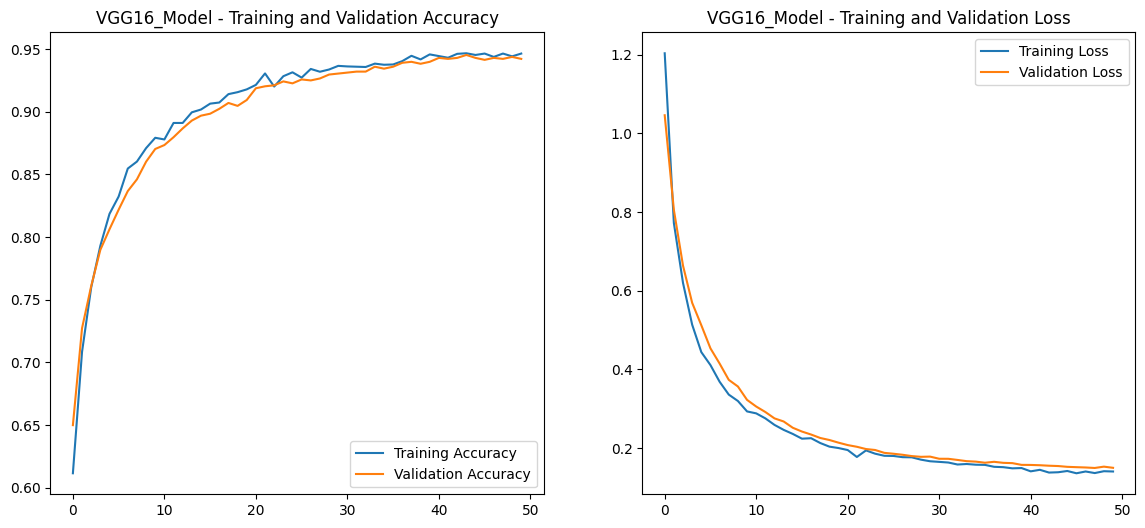

In [10]:
plot_history(vgg_history, "VGG16_Model")

# Custom CNN

In [ ]:
def create_custom_cnn_model(input_shape):
    l2_penalty = 0.001
    
    model = Sequential([
        Input(shape=input_shape),
        
        Conv2D(32, (3, 3), padding='same', activation='relu',
               kernel_regularizer=regularizers.l2(l2_penalty)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        
        Conv2D(64, (3, 3), padding='same', activation='relu',
               kernel_regularizer=regularizers.l2(l2_penalty)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        
        Conv2D(128, (3, 3), padding='same', activation='relu',
                kernel_regularizer=regularizers.l2(l2_penalty)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        
        Flatten(),
        Dense(64, activation='relu',
              kernel_regularizer=regularizers.l2(l2_penalty)),
        BatchNormalization(),
        Dropout(0.5), # Keep this
        Dense(2, activation='softmax')
    ])
    
    optimizer = Adam(learning_rate=0.0005)
    
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print("Custom CNN model built successfully.")
    model.summary()
    return model

custom_cnn_model = create_custom_cnn_model(input_shape=(*IMG_SIZE_CNN, 3))

Custom CNN model built successfully.


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,191,746 (8.36 MB)

 Trainable params: 2,191,170 (8.36 MB)

 Non-trainable params: 576 (2.25 KB)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau


cnn_callbacks = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
    
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001), 
    
    ModelCheckpoint(
        filepath=str(SAVED_MODELS_PATH / 'custom_cnn_best.keras'),
        monitor='val_loss',
        save_best_only=True
    )
]

print("\n--- Training Custom CNN Model ---")
custom_cnn_history = custom_cnn_model.fit(
    train_gen_cnn,
    epochs=EPOCHS,
    validation_data=val_gen_cnn,
    callbacks=cnn_callbacks
)

print("\n--- Custom CNN Training Finished ---")


--- Training Custom CNN Model ---
Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 235ms/step - accuracy: 0.7770 - loss: 0.7939 - val_accuracy: 0.5016 - val_loss: 1.2682 - learning_rate: 5.0000e-04
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 258ms/step - accuracy: 0.7955 - loss: 0.7128 - val_accuracy: 0.8016 - val_loss: 0.6684 - learning_rate: 5.0000e-04
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 261ms/step - accuracy: 0.8127 - loss: 0.6655 - val_accuracy: 0.7688 - val_loss: 0.7723 - learning_rate: 5.0000e-04
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 266ms/step - accuracy: 0.8306 - loss: 0.6147 - val_accuracy: 0.8383 - val_loss: 0.5918 - learning_rate: 5.0000e-04
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 264ms/step - accuracy: 0.8163 - loss: 0.6291 - val_accuracy: 0.8398 - val_loss: 0.6229 - learning_rate: 5.0000e-04
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 266ms/step - accuracy: 0.8257 - loss: 0.5853 - val_accuracy: 0.7633 - val_loss: 0.8922 - learning_rate: 5.0000e-04
Epoch 7/50


Saved plot to CNN_Model_training_history.png


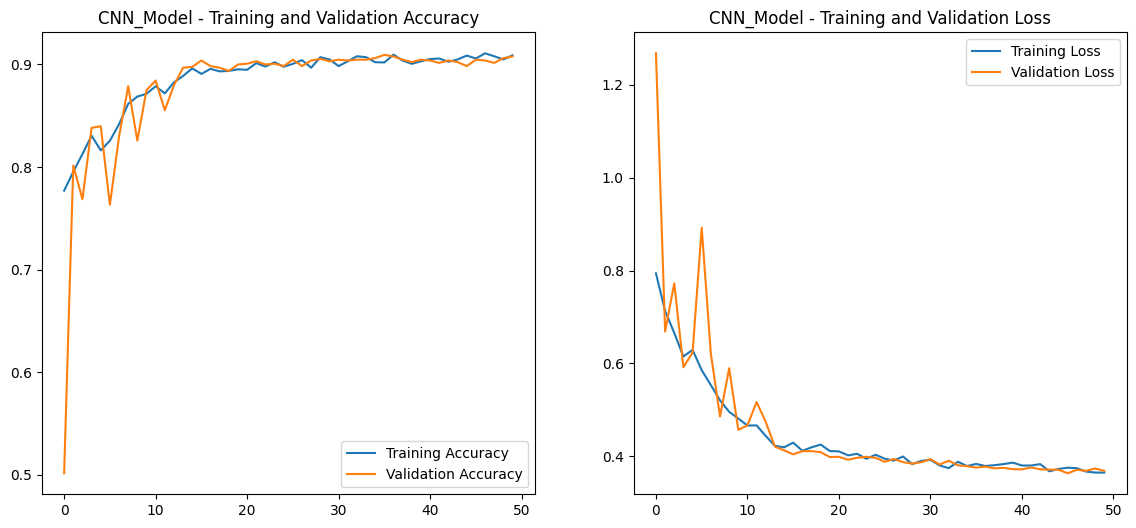

In [29]:
plot_history(custom_cnn_history, "CNN_Model")

# EfficientNetB0

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ReduceLROnPlateau

def create_efficientnet_model(input_shape):
   
    inputs = Input(shape=input_shape)
    
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs,
        pooling='avg'
    )
    
    base_model.trainable = False
    
    x = base_model.output 
    
    x = Dropout(0.3)(x)
    outputs = Dense(2, activation='softmax', name='output_layer')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print("EfficientNetB0 model built successfully.")
    model.summary()
    return model

effnet_model = create_efficientnet_model(input_shape=(*IMG_SIZE_VGG, 3))


EfficientNetB0 model built successfully.


Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ input_layer_7[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_3[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_4[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,052,133 (15.46 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
effnet_callbacks = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001),
    ModelCheckpoint(
        filepath=str(SAVED_MODELS_PATH / 'efficientnet_b0_best.keras'),
        monitor='val_loss',
        save_best_only=True
    )
]

print("\n--- Training EfficientNetB0 Model ---")
effnet_history = effnet_model.fit(
    train_gen_eff,  
    epochs=EPOCHS,
    validation_data=val_gen_eff,
    callbacks=effnet_callbacks
)

print("\n--- EfficientNetB0 Training Finished ---")


--- Training EfficientNetB0 Model ---
Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 68s 462ms/step - accuracy: 0.6114 - loss: 0.6824 - val_accuracy: 0.7688 - val_loss: 0.5240 - learning_rate: 1.0000e-04
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 65s 466ms/step - accuracy: 0.7725 - loss: 0.4950 - val_accuracy: 0.8516 - val_loss: 0.4104 - learning_rate: 1.0000e-04
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 64s 458ms/step - accuracy: 0.8190 - loss: 0.4148 - val_accuracy: 0.8766 - val_loss: 0.3491 - learning_rate: 1.0000e-04
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 66s 470ms/step - accuracy: 0.8616 - loss: 0.3551 - val_accuracy: 0.8844 - val_loss: 0.3108 - learning_rate: 1.0000e-04
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 64s 456ms/step - accuracy: 0.8703 - loss: 0.3324 - val_accuracy: 0.8984 - val_loss: 0.2872 - learning_rate: 1.0000e-04
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 65s 460ms/step - accuracy: 0.8752 - loss: 0.3071 - val_accuracy: 0.9062 - val_loss: 0.2675 - learning_rate: 1.0000e-04
Epoch 7

Saved plot to EfficientNetB0_Model_training_history.png


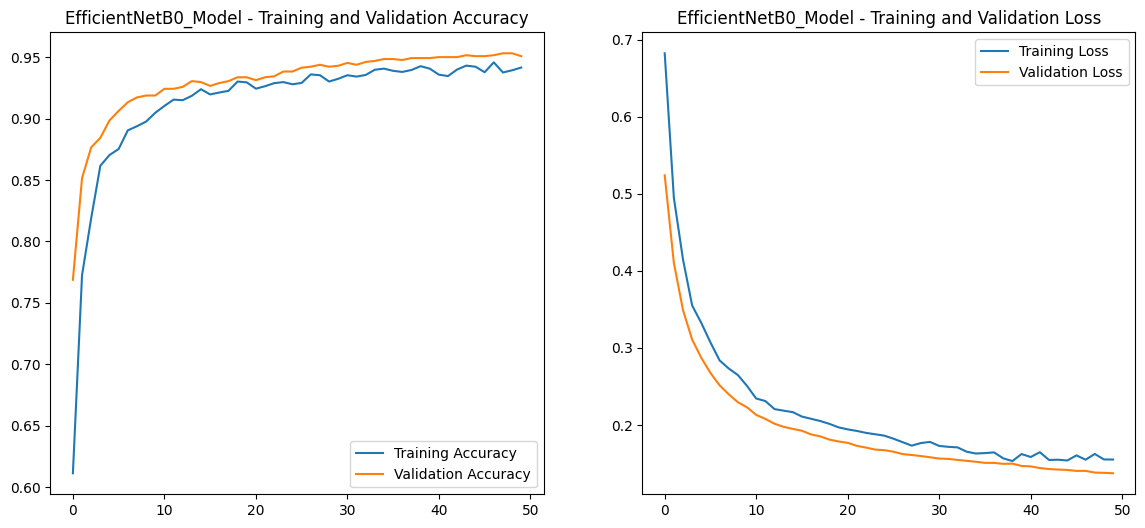

In [38]:
plot_history(effnet_history, "EfficientNetB0_Model")

# Evaluation

In [ ]:
print("\n--- Evaluating Models on Test Set ---")

try:
    best_vgg_model = load_model(str(SAVED_MODELS_PATH / 'vgg16_best.keras'))
    print("Loaded best VGG16 model from checkpoint.")
    vgg_loss, vgg_acc = best_vgg_model.evaluate(test_gen_vgg)
    print(f"VGG16 Test Accuracy: {vgg_acc*100:.2f}%")
    print(f"VGG16 Test Loss: {vgg_loss:.4f}")
except Exception as e:
    print(f"Could not load best VGG16 model, evaluating current model. Error: {e}")
    vgg_loss, vgg_acc = vgg_model.evaluate(test_gen_vgg)
    print(f"VGG16 (current) Test Accuracy: {vgg_acc*100:.2f}%")
    print(f"VGG16 (current) Test Loss: {vgg_loss:.4f}")


try:
    best_cnn_model = load_model(str(SAVED_MODELS_PATH / 'custom_cnn_best.keras'))
    print("\nLoaded best Custom CNN model from checkpoint.")
    cnn_loss, cnn_acc = best_cnn_model.evaluate(test_gen_cnn)
    print(f"Custom CNN Test Accuracy: {cnn_acc*100:.2f}%")
    print(f"Custom CNN Test Loss: {cnn_loss:.4f}")
except Exception as e:
    print(f"\nCould not load best Custom CNN model, evaluating current model. Error: {e}")
    cnn_loss, cnn_acc = custom_cnn_model.evaluate(test_gen_cnn)
    print(f"Custom CNN (current) Test Accuracy: {cnn_acc*100:.2f}%")
    print(f"Custom CNN (current) Test Loss: {cnn_loss:.4f}")

try:
    best_effnet_model = load_model(str(SAVED_MODELS_PATH / 'efficientnet_b0_best.keras'))
    print("Loaded best EfficientNetB0 model from checkpoint.")
    effnet_loss, effnet_acc = best_effnet_model.evaluate(test_gen_eff)
    print(f"EfficientNetB0 Test Accuracy: {effnet_acc*100:.2f}%")
    print(f"EfficientNetB0 Test Loss: {effnet_loss:.4f}")
except Exception as e:
    print(f"Could not load best EfficientNetB0 model. Error: {e}")
    effnet_loss, effnet_acc = effnet_model.evaluate(test_gen_eff)
    print(f"EfficientNetB0 Test Accuracy: {effnet_acc*100:.2f}%")
    print(f"EfficientNetB0 Test Loss: {effnet_loss:.4f}")


--- Evaluating Models on Test Set ---
Loaded best VGG16 model from checkpoint.
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9328 - loss: 0.1617
VGG16 Test Accuracy: 93.28%
VGG16 Test Loss: 0.1617

Loaded best Custom CNN model from checkpoint.
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9016 - loss: 0.4018
Custom CNN Test Accuracy: 90.16%
Custom CNN Test Loss: 0.4018
Loaded best EfficientNetB0 model from checkpoint.
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 272ms/step - accuracy: 0.9500 - loss: 0.1348
EfficientNetB0 Test Accuracy: 95.00%
EfficientNetB0 Test Loss: 0.1348


In [ ]:
print("\n--- Final Comparison ---")
print(f"VGG16 Model (Fine-Tuned):   Test Accuracy = {vgg_acc*100:.2f}%")
print(f"EfficientNetB0 Model (SOTA):  Test Accuracy = {effnet_acc*100:.2f}%")
print(f"Lightweight CNN Model:    Test Accuracy = {cnn_acc*100:.2f}%")
print("--------------------------")

if vgg_acc > cnn_acc and vgg_acc > effnet_acc:
    print("Result: The VGG16 fine-tuned model performed better.")
elif effnet_acc > cnn_acc:
    print("Result: The EfficientNetB0 model performed better.")
else:
    print("Result: The Lightweight Custom CNN performed better.")


--- Final Comparison ---
VGG16 Model (Fine-Tuned):   Test Accuracy = 93.28%
EfficientNetB0 Model (SOTA):  Test Accuracy = 95.00%
Lightweight CNN Model:    Test Accuracy = 90.16%
--------------------------
Result: The EfficientNetB0 model performed better.


# Analysis

In [41]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
eff_acc = 95.00
vgg_acc = 93.28
cnn_acc = 90.16

eff_vs_vgg_rel = (eff_acc - vgg_acc) / vgg_acc * 100
eff_vs_cnn_rel = (eff_acc - cnn_acc) / cnn_acc * 100
vgg_vs_cnn_rel = (vgg_acc - cnn_acc) / cnn_acc * 100

print("--- Relative Percentage Improvement ---")
print(f"EfficientNetB0 was {eff_vs_vgg_rel:.2f}% better than VGG16.")
print(f"EfficientNetB0 was {eff_vs_cnn_rel:.2f}% better than the Lightweight CNN.")
print(f"VGG16 was {vgg_vs_cnn_rel:.2f}% better than the Lightweight CNN.")


In [ ]:
test_gen_eff.reset()
y_pred_probs = best_effnet_model.predict(test_gen_eff)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen_eff.classes
class_names = list(test_gen_eff.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix - EfficientNetB0 Model")
plt.savefig("confusion_matrix_efficientnet.png")
plt.show()

In [ ]:
N_SAMPLES = 5
if len(test_df) >= N_SAMPLES:
    sample_df = test_df.sample(n=N_SAMPLES)
    
    prediction_results = []
    
    for index, row in sample_df.iterrows():
        img_path = row['filepath']
        true_label = row['label']

        img_eff = load_img(img_path, target_size=IMG_SIZE_VGG)
        arr_eff = img_to_array(img_eff)
        arr_eff = np.expand_dims(arr_eff, axis=0)
        
        img_vgg = load_img(img_path, target_size=IMG_SIZE_VGG)
        arr_vgg = img_to_array(img_vgg)
        arr_vgg = vgg_preprocess(arr_vgg)
        arr_vgg = np.expand_dims(arr_vgg, axis=0)
        
        img_cnn = load_img(img_path, target_size=IMG_SIZE_CNN)
        arr_cnn = img_to_array(img_cnn) / 255.0
        arr_cnn = np.expand_dims(arr_cnn, axis=0)

        pred_eff = class_names[np.argmax(best_effnet_model.predict(arr_eff, verbose=0))]
        pred_vgg = class_names[np.argmax(best_vgg_model.predict(arr_vgg, verbose=0))]
        pred_cnn = class_names[np.argmax(best_cnn_model.predict(arr_cnn, verbose=0))]
        
        prediction_results.append({
            "Image": Path(img_path).name,
            "True Label": true_label,
            "EfficientNetB0": pred_eff,
            "VGG16": pred_vgg,
            "Lightweight CNN": pred_cnn
        })
        
    results_df = pd.DataFrame(prediction_results)
    
    print(results_df.to_markdown(index=False))